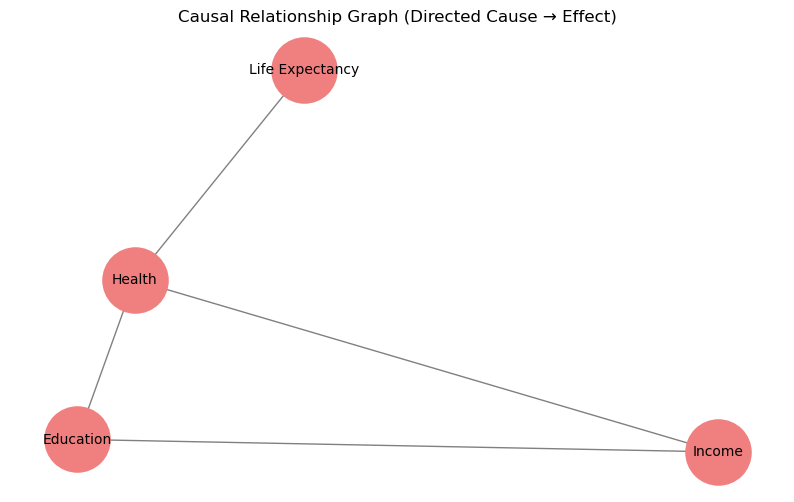

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# -----------------------------
# Simulated causal system
# -----------------------------
np.random.seed(42)
n = 120

education = np.random.normal(14, 2, n)

# CAUSAL STEP 1: education affects income
income = education * 4500 + np.random.normal(0, 5000, n)

# CAUSAL STEP 2: income affects health
health = income / 1200 + np.random.normal(0, 4, n)

# CAUSAL STEP 3: health affects life expectancy
life_expectancy = health * 0.35 + np.random.normal(0, 2, n)

df = pd.DataFrame({
    "Education": education,
    "Income": income,
    "Health": health,
    "Life Expectancy": life_expectancy
})

# -----------------------------
# Build causal graph
# -----------------------------
G = nx.DiGraph()

causal_edges = [
    ("Education", "Income"),
    ("Income", "Health"),
    ("Health", "Life Expectancy"),
    ("Education", "Health")  # indirect + confounding pathway
]

G.add_edges_from(causal_edges)

# -----------------------------
# Layout
# -----------------------------
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)

# Nodes
nx.draw_networkx_nodes(G, pos, node_size=2200, node_color="lightcoral")

# Edges (direction matters)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20, edge_color="gray")

# Labels
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Causal Relationship Graph (Directed Cause → Effect)")
plt.axis("off")
plt.show()